In [1]:
from jax import config
config.update("jax_enable_x64", True)
from pathlib import Path
import glob 
import pandas as pd 

In [2]:
import matplotlib.pyplot as plt 
#from spectres import spectres
import numpy as np
import jax.numpy as jnp 
import pickle 

from astropy.io import fits 
from astropy.table import Table
import os 

In [3]:
from sheap import Sheapectral 
from sheap.Utils.SpectralReaders import parallel_reader 

In [4]:
with open("Pan25_montecarlo_rachi.pkl", "rb") as f:
    dict_spectra = pickle.load(f)

In [ ]:
sheapspectral = Sheapectral(dict_spectra["spectra"],z=dict_spectra["z"],coords=dict_spectra["coords"],names=dict_spectra["names"])

extinction correction will be do it, change 'extinction_correction' to done if you want to avoid this step
redshift correction will be do it, change 'redshift_correction' to done if you want to avoid this step


In [20]:
add_host_miles = {"z_include":None,"age_include":None}
#z_include: Optional[Union[tuple[float, float], list[float]]] = [-0.7, 0.22],
#age_include: Optional[Union[tuple[float, float], list[float]]] = [0.1, 10.0],
sheapspectral.makemodel(limits=(1750,4400),n_broad=2,n_narrow=0,group_method=True,fe_mode ="template",continuum_profile="powerlaw"
                          ,add_winds=False,
                           add_outflow=True,
                           add_host_miles = None,
                           add_balmerhighorder_continuum=True,
                           add_balmer_continuum=True)

sheapspectral.fitmodel(list_num_steps=[2_000],list_learning_rate=[1e-2],run_fit=True)

Fitting 500 spectra with 7781 wavelength pixels

STEP1 (step1) params to minimize 52
learning_rate: 0.01 num_steps: 2000 non_optimize_in_axis: 4
Time for step 'step1': 67.58 seconds
The entire process took 67.58 (0.14s by spectra)


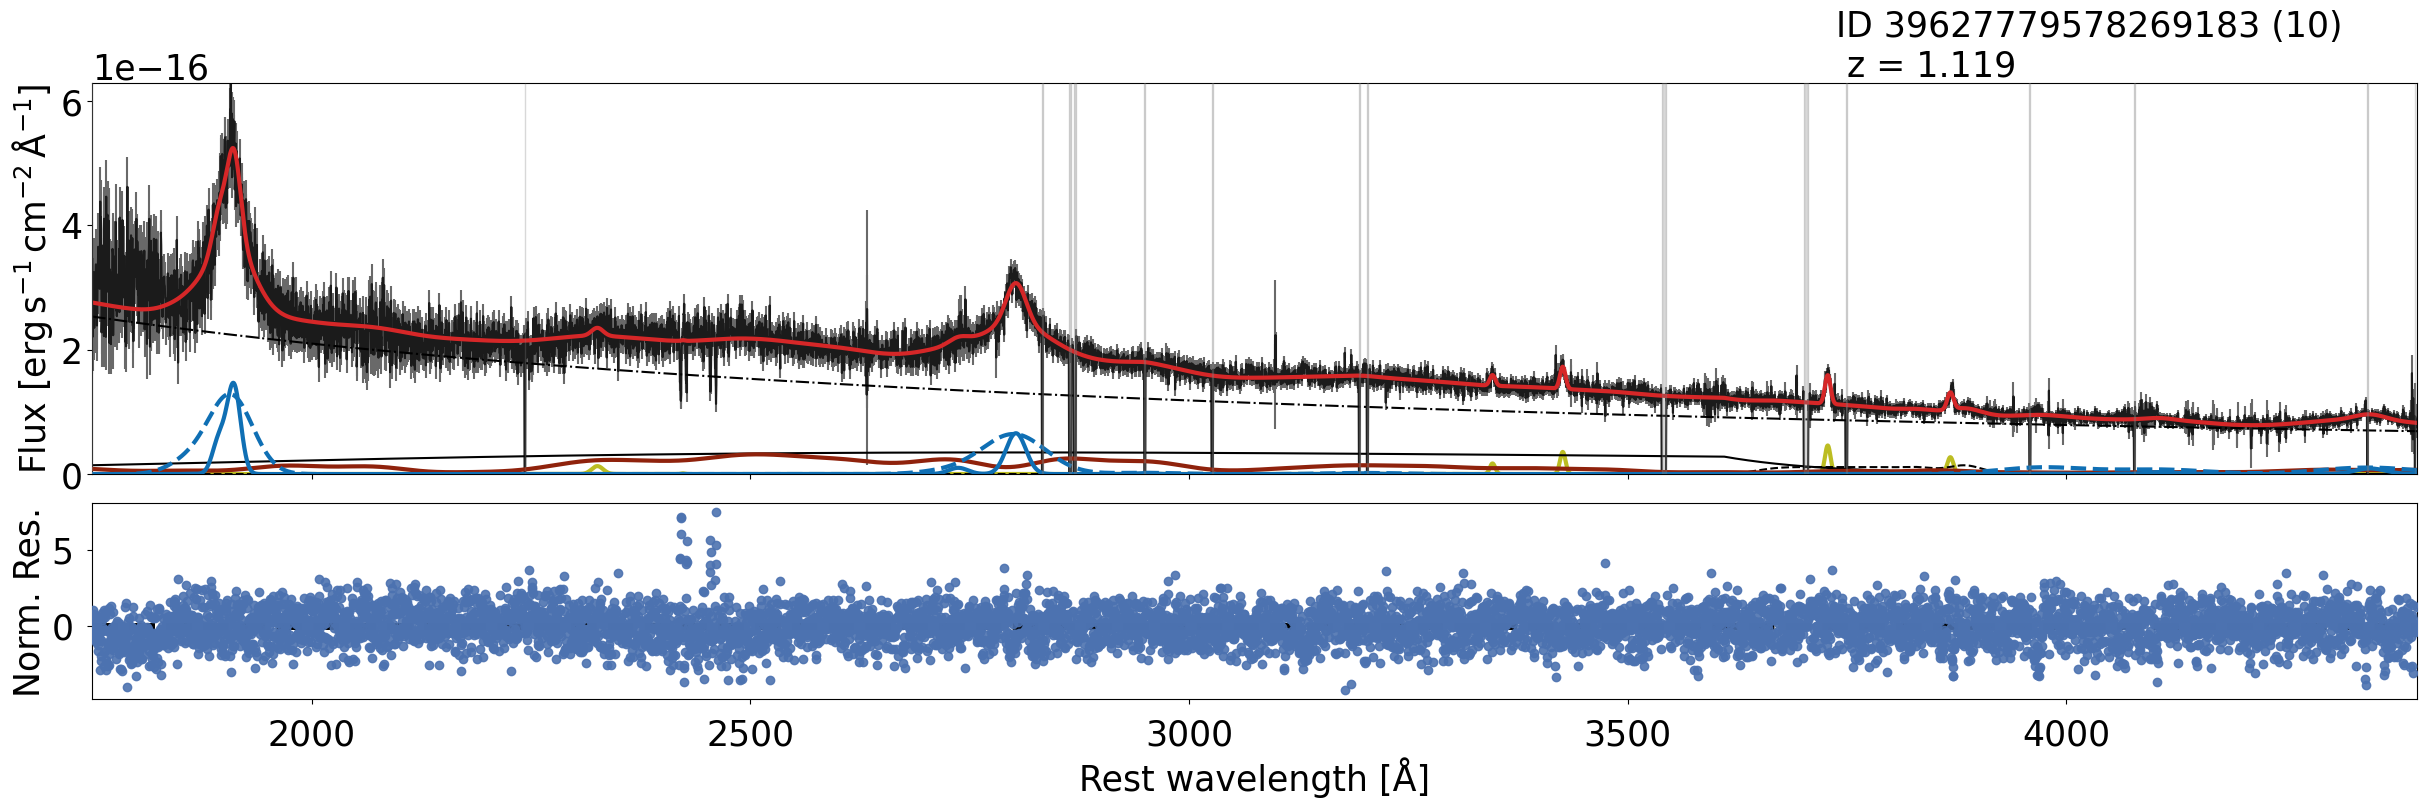

In [22]:
#2050
sheapspectral.plotter.plot(10,add_legend=False,add_lines_name=False)#,add_xline=[1990,2100])#, xlim=[1900,2500]

In [23]:
sheapspectral.estimate_posteriors(sampling_method="montecarlo",overwrite=True,summarize=False,num_samples= 50)
sheapspectral.save_to_pickle("Pan25_montecarlo_rachi_model2.pkl")

Running Monte Carlo with JAX.,sample over the spectra using init params


Getting posterior-params: 100%|██████████| 500/500 [02:56<00:00,  2.84it/s]


Estimated pickle size: 182831.08 KB


In [45]:
# np.argsort(sheapspectral.result.chi2_red)

NaN / non-finite entries at indices: []
Number of NaNs / non-finite values: 0


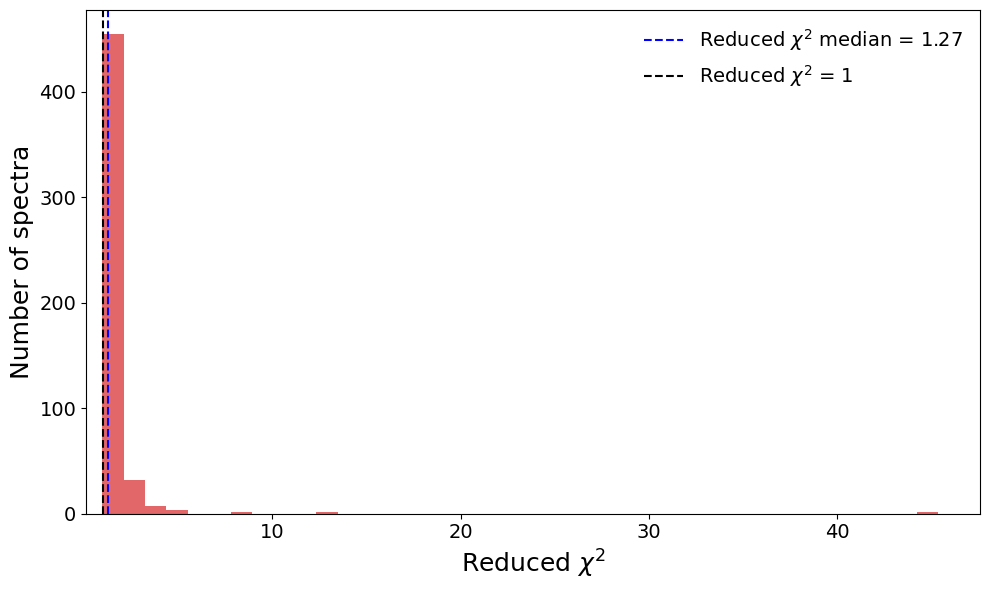

: 

In [ ]:
sheapspectral.plot_chi2

NaN / non-finite entries at indices: []
Number of NaNs / non-finite values: 0


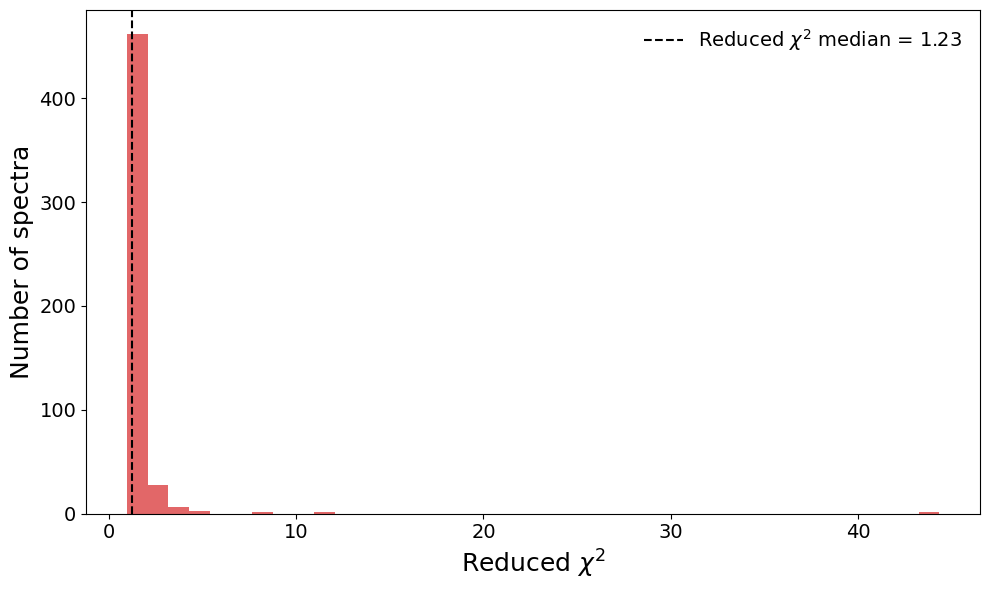

In [256]:
sheapspectral.plot_chi2

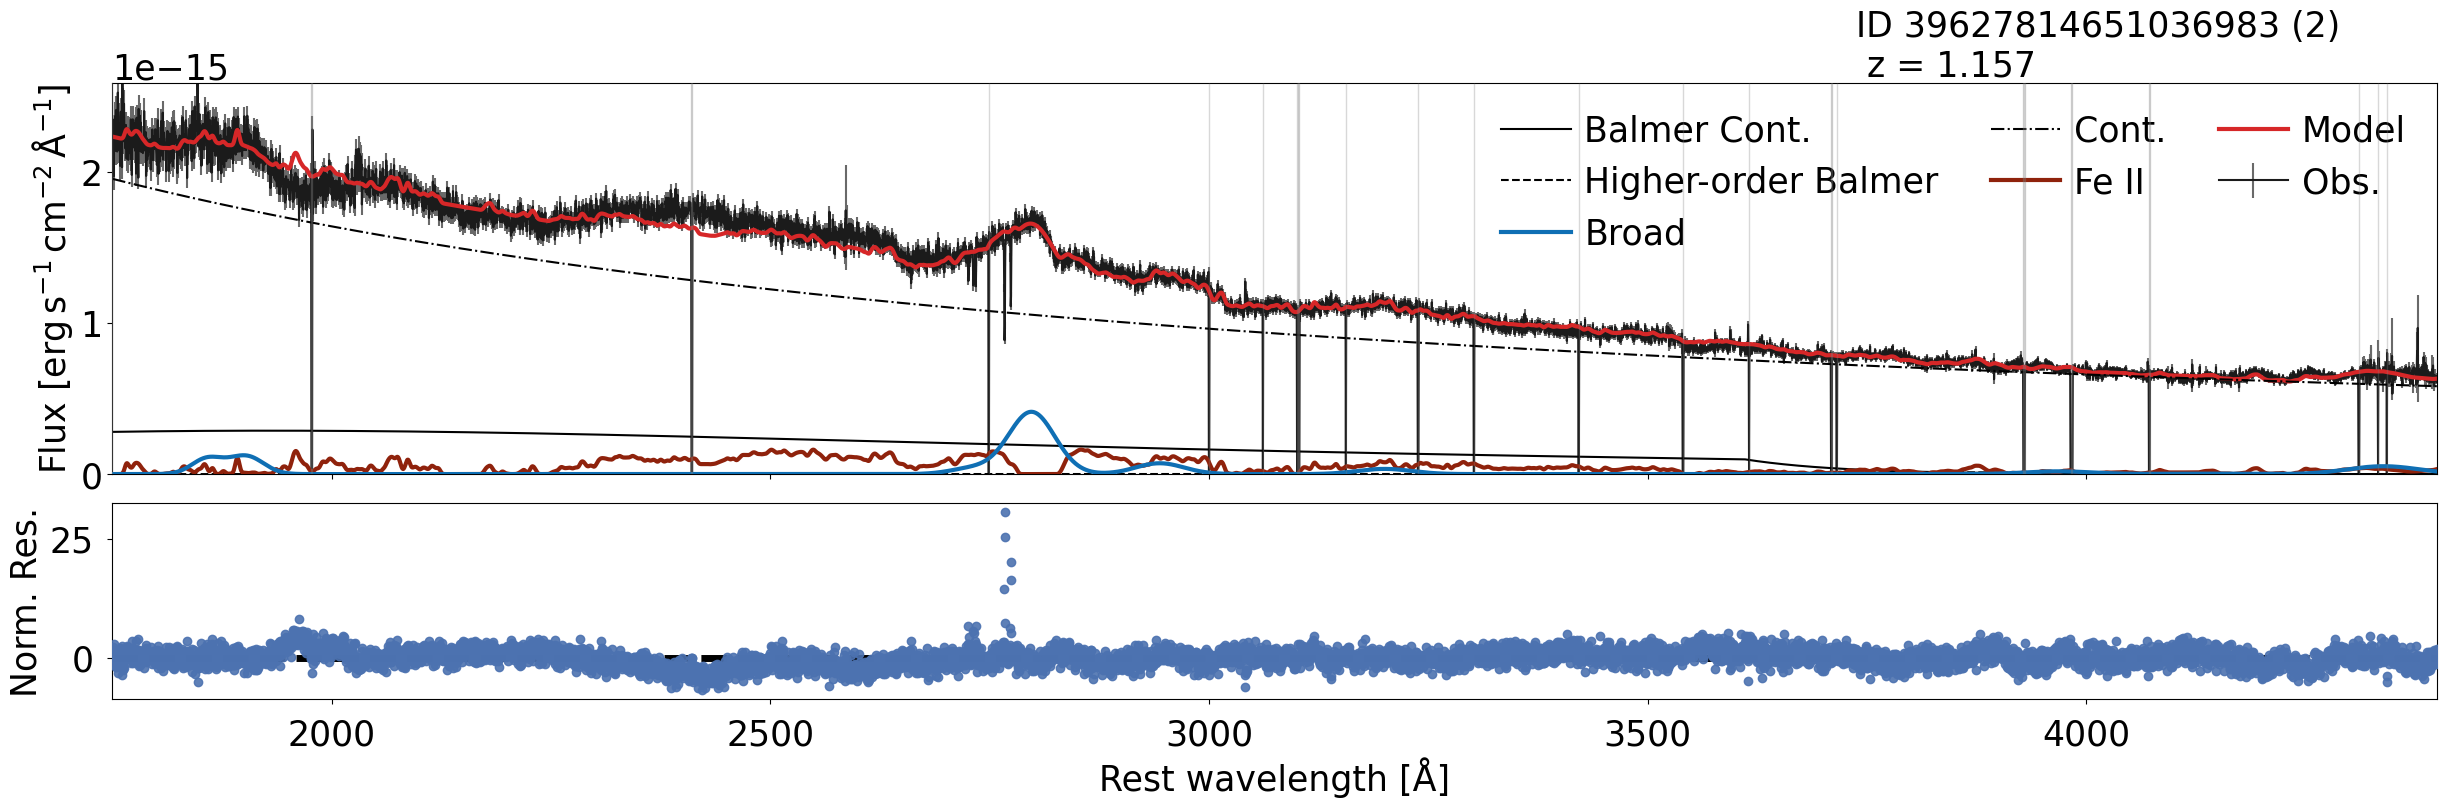

In [44]:
sheapspectral.modelplot.plot(2,add_legend=True)